In [1]:
# Import libraries
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Import libraries and packages accordingly for neural networks
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
# from torch.utils.data import DataLoader
from torch.utils.data.dataloader import DataLoader
import torchvision.transforms as transforms
from torchvision import models
from torchvision.datasets import ImageFolder


In [2]:
import tqdm # progress bar
import torch
import monai # PyTorch and Monai are good combo for Xray and MRI
import cv2 # openai
from PIL import Image # Handle different type of images
import ipywidgets as widgets

from monai.config import print_config
from monai.data import decollate_batch
from monai.metrics import ROCAUCMetric
from monai.networks.nets import DenseNet121
from monai.transforms import (
    Activations,
    EnsureChannelFirst,
    AsDiscrete,
    Compose,
    LoadImage,
    RandFlip,
    RandRotate, 
    RandZoom,
    ScaleIntensity, 
    Resize, 
    ToTensor
)

from monai.utils import set_determinism

In [3]:
import glob
import random
import shutil
from tqdm.auto import tqdm
import copy
import io
import PIL
from PIL import Image


In [5]:
# print_config()

What to do:
- Dataset size 😄
- Class distribution (imbalance)
- Example images per class 😄
- Image dimensions / channels
- Corrupted or unreadable files
- Train/val/test/split strategy 😄
- Initial observations (noise, blur, artifacts, etc)

### Conclusions might be:
- Classes are imbalance (glioma dominates, etc)
- Image vary in resolution
- Some img have low contrast - helpful or not


In [4]:
# Set deterministic training for reproducibility
set_determinism(seed=42)

In [5]:
# Define data paths
# BASE_DIR =  r'D:/ai_brain_tumor_dashboard/data/' # Literal paths
BASE_DIR = r'D:\ai_brain_tumor_dashboard\data'
TRAINING_FOLDER = os.path.join(BASE_DIR, 'Training')
TESTING_FOLDER = os.path.join(BASE_DIR, 'Testing')
VAL_FOLDER = os.path.join(BASE_DIR, 'Validation')
CLASSES = sorted(os.listdir(TRAINING_FOLDER))

In [ ]:
# Create validation datset and move 10% of the training into validation folder
image_files = glob.glob(os.path.join(TRAINING_FOLDER, '**/*.jpg'), recursive= True)
num_classes = 4
selected_images = random.sample(image_files, int(len(image_files)*0.1))

In [ ]:
#Move the selected images to the validation directory
for image_path in tqdm(selected_images):
    #Get the class name from parent directory
    class_folder = os.path.basename(os.path.dirname(image_path))

    # Create a new folder in the validation directory for the current class
    val_class_path = os.path.join(VAL_FOLDER, class_folder)
    if not os.path.exists(val_class_path):
        os.makedirs(val_class_path)

    # Move the image to the corresponding validation class folder
    val_image_path = os.path.join(val_class_path, os.path.basename(image_path))
    shutil.move(image_path, val_image_path)

In [6]:
folders = [TRAINING_FOLDER, VAL_FOLDER, TESTING_FOLDER]
train_size, val_size, test_size = [len(glob.glob(os.path.join(folder, '**/*.jpg'), recursive = True)) for folder in folders]


In [7]:
# Checking the number of images in Traning/Testing/Validation files
print(f'Train size: {train_size}\nValidation Size: {val_size}\nTest Size: {test_size}')

Train size: 5141
Validation Size: 571
Test Size: 1311


In [8]:
## Printing dimension and class distribution of the training folder

class_name = sorted(x for x in os.listdir(TRAINING_FOLDER) if os.path.isdir(os.path.join(TRAINING_FOLDER, x)))
num_classes = len(class_name)
total_image_files = [[os.path.join(TRAINING_FOLDER, class_name[i], x) for x in os.listdir(os.path.join(TRAINING_FOLDER, class_name[i]))]
                     for i in range(num_classes)]

num_each = [len(total_image_files[i]) for i in range(num_classes)]
image_files_list = []
image_class = []

for i in range(num_classes):
    image_files_list.extend(total_image_files[i])
    image_class.extend([i] * num_each[i])
num_total = len(image_class)
image_width, image_height = PIL.Image.open(image_files_list[0]).size

print(f"Total Image counts: {num_total}")
print(f"Total dimensions: {image_width} * {image_height}")
print(f"label_names: {class_name}")
print(f"Label counts: {num_each}")


Total Image counts: 5141
Total dimensions: 512 * 512
label_names: ['glioma', 'meningioma', 'notumor', 'pituitary']
Label counts: [1184, 1196, 1456, 1305]


We can see that the distribution is fairly even between 4 classes with `notumor` type slighly more than the rest of 3

### Pipeline class for EDA

In [9]:
# Pipeline class for the EDA
class EDA:
    def __init__(self, training_folder, testing_folder, valid_folder, classes):
        self.training_folder = training_folder
        self.testing_folder = testing_folder
        self.valid_folder = valid_folder
        self.classes = classes

    def plot_samples(self):
        """
        Function to plot training samples
        """
        fig, ax = plt.subplots(1, 4, figsize=(10, 6))
        for idx, data in enumerate(self._get_training_samples().items()):
            cls, path = data
            img = cv2.imread(path)
            ax[idx].imshow(img)
            ax[idx].set_title(cls)
            ax[idx].axis('off')
        plt.show()

    def plot_counts(self, set_type):
        """
        Function to plot distribution counts.
        :param self: Description
        :param set_type (str): sets to plot counts for. Options: `train` & `set`
        """
        counts = self._get_counts(set_type=set_type)
        X = list(counts.keys())
        y = list(counts.values())

        # Plot counts
        plt.bar(X, y)
        plt.title(f'{set_type.capitalize()} Set Distribution')
        plt.xlabel('Class')
        plt.ylabel('Counts')
        plt.show()

    def _get_training_samples(self):
        """
        Function to retrieve a list of one sample per each class from training folder
        """
        paths = [os.path.join(self.training_folder, cls) for cls in self.classes]
        img_paths = {}
        for path, cls in zip(paths, self.classes):
            img_name = sorted(os.listdir(path))[0]
            img_paths[cls] = os.path.join(path, img_name)
        return img_paths
            
    def _get_counts(self, set_type):
        """
        Function to get the count of each class in a given set
                
        :param `set_type`: get counts for either `train` and `test`
        return dictionary of counts
        """
        if set_type=='train':
            folder = self.training_folder
        elif set_type == 'test':
            folder = self.testing_folder
        else:
            folder = self.valid_folder

        counts = {}

        #Iterate through class
        for class_type in self.classes:
            dir = os.path.join(folder, class_type)
            counts[class_type] = len(os.listdir(dir))
            
        return counts

## Data Distribution

In [62]:
# initialize explorer
eda = EDA(TRAINING_FOLDER, TESTING_FOLDER, VAL_FOLDER, CLASSES)

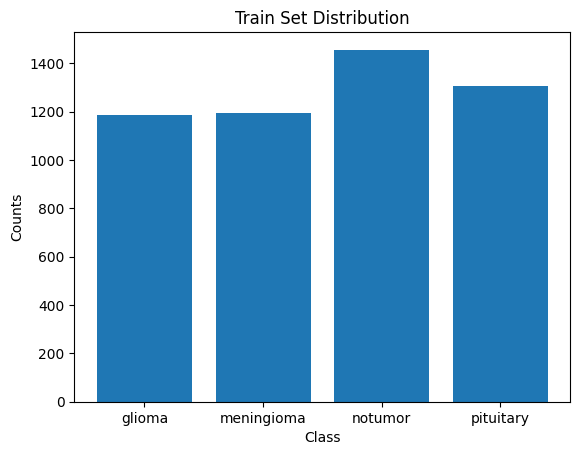

In [31]:
# Plot train counts
eda.plot_counts('train')

In [10]:
# Plot validation counts
eda.plot_counts('valid')

NameError: name 'eda' is not defined

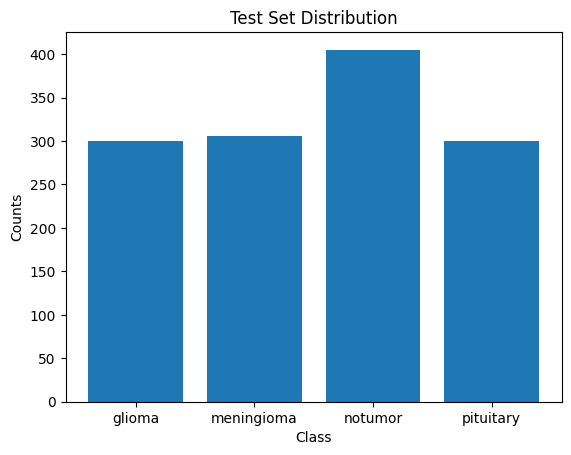

In [13]:
# Plot test count
eda.plot_counts('test')

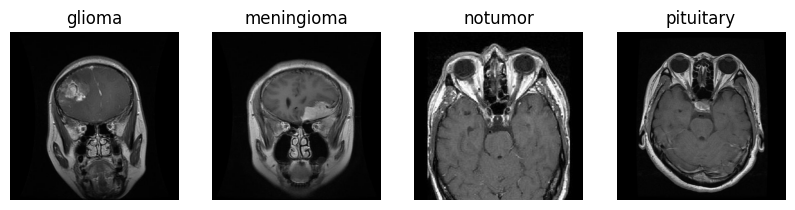

In [63]:
# Plot samples
eda.plot_samples()

## Preprocess data

### 1. Configuration

In [11]:
class Config:
    batch_size = 32
    epochs = 50
    lr = 1e-4
    n_classes = len(CLASSES)
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### 2. Data Preparation


In [26]:
## Define MONAI transform to "prepare/augment" train/test/val datasets
train_transform = Compose([
    lambda x: np.array(x.convert("RGB")), 
    EnsureChannelFirst(channel_dim=-1),
    Resize(spatial_size=(224, 224)),
    ScaleIntensity(),
    RandRotate(range_x=np.pi / 12, prob = 0.5, keep_size=True),
    RandFlip(spatial_axis=0, prob=0.5),
    RandZoom(min_zoom=0.9, max_zoom=1.1, prob=0.5)
])  

# Transform validation dataset
val_transformation = Compose([
    lambda x: np.array(x.convert("RGB")), 
    Resize(spatial_size=(224, 224)), 
    EnsureChannelFirst(channel_dim=-1),
    ScaleIntensity() # No use Rotation or Flip, we want to see how good our image is performing under "real" condition after learning through tons of flipping and rotating images
])

y_pred_trans = Compose([
    Activations(softmax=True)
])
y_trans = Compose([
    AsDiscrete(to_onehot=num_classes)
])
      

In [27]:
# Create dataset
train_dataset = ImageFolder(TRAINING_FOLDER, transform=train_transform)
val_dataset = ImageFolder(VAL_FOLDER, transform=val_transformation)
test_dataset = ImageFolder(TESTING_FOLDER, transform=val_transformation)

# Make sure all of the labels are in the correct order
assert train_dataset.classes == val_dataset.classes == test_dataset.classes
print(train_dataset.classes)

['glioma', 'meningioma', 'notumor', 'pituitary']


### 3. Models selection - 2 - (including loss and optimizer)

In [28]:
# We'll experiment with 2 transfer learning models: DenseNet121 and VGG16
# Define DenseNet model and optimizer
dense_model = DenseNet121(spatial_dims=2, in_channels=3, out_channels=num_classes).to(device)
loss_function = torch.nn.CrossEntropyLoss() # Calculate how far off the models' prediction from the real answer
optimizer = torch.optim.Adam(dense_model.parameters(), lr = Config.lr)
max_epochs= 5
val_interval = 1
auc_metric = ROCAUCMetric()

In [23]:
class EarlyStopping():
    """
    Create an early stopping callback that will stop the training 
    and restore the best weights when a certain patience interval is hit.
    """

    def __init__(self, patience=5, min_delta=0, restore_best_weights=True):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights
        self.best_model = None
        self.best_loss = None
        self.counter = 0
        self.status = ''

    def __call__(self, model, val_loss):
        if self.best_loss == None: # Save the current loss as the "best" and keeps a copy of the model
            self.best_loss = val_loss
            self.best_model = copy.deepcopy(model)
        elif self.best_loss - val_loss > self.min_delta: # if the model get better by significant amount?
            self.best_loss = val_loss # update best loss
            self.counter = 0 # Reset counter to 1
            self.best_model.load_state_dict(model.state_dict()) # Save new best model weights
        elif self.best_loss - val_loss < self.min_delta: # If the model stays the same or got worse
            self.counter +=1
            if self.counter >= self.patience: # Counter reaches patience limit
                self.status = f"Stopped on {self.counter}"
                if self.restore_best_weights: # Restore best weights
                    model.load_state_dict(self.best_model.state_dict())
                return True
        self.status = f'{self.counter}/{self.patience}'
        return False

### 4. Model training
Define a class that will be used as a trainer. This will train, evaluate and save the model weights (incooporate early stopping, plot training, and predict)

In [24]:
class BrainTumorClassifier:
    def __init__(self, model, optimizer, criterion, val_transformations, train_dataset, config, output_folder=None):
        self.model = model
        self.optimizer = optimizer
        self.criterion = criterion
        self.output_folder = 'torch_models/' if output_folder is None else output_folder
        self.history = {}
        self.val_transformations = val_transformations
        self.classes = train_dataset.classes
        self.Config = config

    def train(self, training_loader, eval_loader, num_epochs, output_filename):
        """
        Method to train the model for a given number of epochs using the provided training and evaluation data loaders

        Args:
            training_loader (torch.utils.data.dataloader.DataLoader): PyTorch data loader for training data
            eval_loader (torch.utils.data.dataloader.DataLoader): PyTorch data loader for evaluation data
            num_epochs (int): Number of epochs to train the model.
            output_filename (str): Name of file to save the trained model to.

        Returns:
            None. Trains the model and saves it to the specified output directory
        """

        # Create output directory
        if not os.path.exists(self.output_folder):
            os.makedirs(self.output_folder)
        file_dir = os.path.join(self.output_folder, output_filename)

        # Initialize metrics
        train_accuracies, train_losses = [], []
        val_accuracies, val_losses = [], []
        
        # Define early stopping variables
        early_stopper = EarlyStopping()
        best_epoch = 0
        best_val_loss = np.inf

        for epoch in range(num_epochs):
            print(f"Epoch {epoch+1}/{num_epochs}")

            #Train one epoch
            train_acc, train_loss = self._train_epoch(training_loader)
            train_accuracies.append(train_acc)
            train_losses.append(train_loss)

            #Eval one epoch
            val_acc, val_loss = self._eval_epoch(eval_loader)
            val_accuracies.append(val_acc)
            val_losses.append(val_loss)

            print()

            #Update the best model weights
            if val_loss < best_val_loss:
                best_val_loss = val_loss #Update the best val loss
                best_epoch = epoch+1 # Update best epoch for best val loss

            # Check for early stopping
            if early_stopper(self.model, val_loss):
                print(f"Validation loss has not improved for {early_stopper.patience} epochs. Early Stopping...")
                print(f"Reverting back to weights for epoch {best_epoch}.")
                break

            # End of training
            print("Training finished!")

            # Save model
            torch.save(self.model.state_dict(), file_dir)

            # Get history
            self.history = {
                'accuracy': {'train': train_accuracies, 'eval': val_accuracies}, 
                'loss': {'train': train_losses, 'eval': val_losses}
            }

    def plot_training(self):
        """
        Plots the training and validation accuracy and loss over each epoch. Retrieves the accuracy and loss
        values from the `self.history` dictionary and creates two subplots to display the accuracy and loss
        data separately.
        """

        # Get the accuracies and loss values from self.history
        train_accuracies = self.history['accuracy']['train']
        val_accuracies = self.history['accuracy']['eval']
        train_losses = self.history['loss']['train']
        val_losses = self.history['loss']['eval']

        # Create subplots for accuracies and loss plots
        fig, axs = plt.subplots(2, 1, figsize = (10, 6))
        fig.subplots_adjust(hspace = 0.5)

        # Plot training and validation accuracies
        axs[0].plot(train_accuracies, label = 'Training accuracy')
        axs[0].plot(val_accuracies, label = 'Validation accuracy')
        axs[0].set_title("Accuracy")
        axs[0].set_xlabel("Epoch")
        axs[0].set_ylabel("Accuracy")
        axs[0].legend()

        # Plot training and validation losses
        axs[1].plot(train_losses, label = 'Training losses')
        axs[1].plot(val_losses, label = "Validation losses")
        axs[1].set_title("Loss")
        axs[1].set_xlabel("Epoch")
        axs[1].set_ylabel("Loss")
        axs[1].legend()

        plt.show()

    def evaluate(self, test_loader):
        """
        Evaluates the model on a given test loader and returns the accuracy and loss metrics. 
        Uses the 'eval_epoch' method to calculate the metrics for each batch in the loader and returns the fina
        metrics for the entire dataset.

        Args: 
            test_loader (torch.utils.data.dataloader.DataLoader): PyTorch DataLoader for the test dataset

        Returns:
            Tuple of the average accuracy and loss the dataset
        """
        return self._eval_epoch(test_loader, return_metrics= False)
    
    def predict(self, img):
        """
        Takes an image and returns the predicted class label. Applies the validation transformations to the
        image, performs a forward pass through the model, and returns the predicted class.

        Args:
            img: PIL image object of the input image
        Returns:
            The predicted class label as a string
        """
        self.model.eval()
        img = self.val_transformations(img)
        img = torch.unsqueeze(img, 0)
        img = img.to(self.Config.device)
        pred = self.model(img)
        pred_idx = torch.argmax(pred, dim=1)
        return self.classes[pred_idx]
    
    def _train_epoch(self, training_loader):
        """
        Train a single epoch of the model

        Args:
            training_loader (torch.utils.data.DataLoader): The PyTorch data loader object for the training set

        Returns:
            Tuple of floats: The average training accuracy and avergae training loss for the epoch.    
        """
        running_loss = 0.00
        running_acc = 0.00
        self.model.train()

        prog_bar = tqdm(enumerate(training_loader), total = len(training_loader))
        for batch_idx, (imgs, labels) in prog_bar:

            # Configure to device
            imgs, labels = imgs.to(self.Config.device), labels.to(self.Config.device)

            # Zero out gradients
            self.optimizer.zero_grad()

            # Forward pass
            outputs = self.model(imgs)
            loss = self.criterion(outputs, labels)

            #Backward pass
            loss.backward()
            self.optimizer.step()

            # Calculate loss of batch in average
            running_loss += loss.item()

            # Calculate accuracy
            running_acc += (outputs.argmax(-1) == labels).float().mean().item()
            avg_loss = running_loss / (batch_idx + 1)
            avg_acc = running_acc / (batch_idx + 1)

            prog_bar.set_description(f" Batch {batch_idx+1} / {len(training_loader)} - Avg Train Loss: {avg_loss:.4f}, Avg Train Accuracy: {avg_acc:.4f}")
        return avg_acc, avg_loss
    
    def _eval_epoch(self, eval_loader, return_metrics = True):
        """
        Evaluate the performance of the model on a validation set for a single epoch.

        Args:
            eval_loader (torch.utils.data.dataloader.DataLoader): PyTorch validation loader
            return_metrics (bool): Whether to return the evaluation metrics (accuracy and loss).

        Returns:
            tuple: a tuple containing the evaluation metrics. The first element is the average validation accuracy,
            and the 2nd one  if the average validation loss.
        """

        running_loss = 0.00
        running_acc = 0.00

        self.model.eval()
        prog_bar = tqdm(enumerate(eval_loader), total = len(eval_loader))
        for batch_idx, (imgs, labels) in prog_bar:

            # Configure to device
            imgs, labels = imgs.to(self.Config.device), labels.to(self.Config.device)

            # Forward pass
            outputs = self.model(imgs)
            loss = self.criterion(outputs, labels)

            # Calculate the loss of batch in average
            running_loss += loss.item()

            # Calculate accuracy
            running_acc += (outputs.argmax(-1) == labels).float().mean().item()

            avg_loss = running_loss / (batch_idx+1)
            avg_acc = running_acc / (batch_idx+1)

            prog_bar.set_description(f"Batch {batch_idx+1}/{len(eval_loader)} - Avg Val Loss: {avg_loss:.4f}, Avg Val Accuracy: {avg_acc:.4f}")

        if return_metrics:
            return avg_acc, avg_loss


In [ ]:
# Create the "trainer" instance

trainer = BrainTumorClassifier(model=dense_model, optimizer=optimizer,
                                criterion = loss_function, val_transformations = val_transformation, 
                                train_dataset=train_dataset, config=Config, output_folder="../models/densenet_v1/")

# Start the training
# 1. Create the Loaders
train_loader = DataLoader(train_dataset, batch_size=Config.batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=Config.batch_size, shuffle=False)

# 2. Start the Training (Notice the names must match the Class definition)
trainer.train(
    training_loader = train_loader, 
    eval_loader = val_loader, 
    num_epochs = Config.epochs, 
    output_filename = "best_model.pth"
)

Epoch 1/50


  0%|          | 0/161 [00:00<?, ?it/s]

### VGG16

In [ ]:
# ### Define VGG16 model
# import torch
# import torchvision.models as models

# # Loading VGG16 with pre-trained weights
# vgg16 = models.vgg16(weights='IMAGENET1K_V1')

# # Build the CNN using `torch.nn.Module` class and the VGG16 pretrained architecture
# class Net(nn.Module):
#     def __init__(self, num_classes):
#         super(Net, self).__init__()

#         # Load in VGG16
#         num_input_features = vgg16.classifier[6].in_features

#         # Freeze layers
#         for param in vgg16.parameters():
#             param.requires_grad = False
        
#         # Define feed forward network
#         vgg16.classifier[6] = nn.Linear(num_input_features, num_classes)
#         for param in vgg16.classifier.parameters():
#             param.requires_grad = False

#         self.model = vgg16

#     def forward(self, x):
#         return self.model(x)

    

In [ ]:
# # Initialize params for VGG16
# model = Net(num_classes = Config.n_classes).to(Config.device)
# optimizer = optim.Adam(model.parameters(), lr = Config.lr)
# criterion = nn.CrossEntropyLoss()
# output_folder = " D:\ai_brain_tumor_dashboard"